In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import re

In [8]:
data_path = os.path.join('result', 'result.csv')

df = pd.read_csv(data_path)
df

,num_gu,epoch,train_loss,val_loss,time
0,2,1,-12.031624,-12.087915,3.161126
1,2,2,-12.137347,-12.198574,2.810247
2,2,3,-12.163795,-12.167590,2.930215
3,2,4,-12.198584,-12.302960,2.899147
4,2,5,-12.268087,-12.299289,2.915156
...,...,...,...,...,...
4995,6,996,-11.948741,-11.985710,6.228588
4996,6,997,-11.940349,-11.983092,6.192512
4997,6,998,-11.957581,-11.984738,6.158423
4998,6,999,-11.947587,-11.983342,6.152320


In [9]:
# !fc-list | grep -i "Times New Roman"

In [10]:
num_gu_ls = pd.unique(df['num_gu'])
avg_time = [np.mean(df[df['num_gu'] == num_gu]['time']) for num_gu in num_gu_ls]
se_ls = [-(df[df['num_gu'] == num_gu]['val_loss'].iloc[-1]) for num_gu in num_gu_ls]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


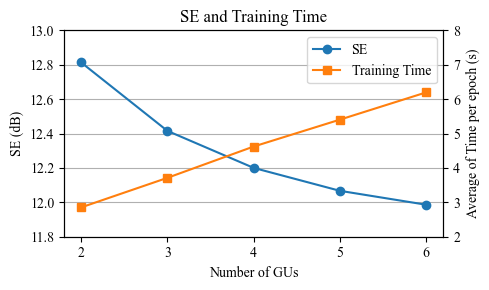

In [11]:
# Times New Roman 폰트 적용
# mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf')
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax1 = plt.subplots(figsize=(5, 3))
ax2 = ax1.twinx()  # 오른쪽 y축

# grid를 bar 뒤에 그리도록 설정
ax1.set_axisbelow(True)
ax2.set_axisbelow(True)

# 왼쪽 y축: Spectral Efficiency (SE)
bars1 = ax1.plot(num_gu_ls, se_ls, marker='o', color='tab:blue', label='SE', zorder=3)
ax1.set_ylabel("SE (dB)")
ax1.tick_params(axis='y')
ax1.set_ylim(11.8, 13)
ax1.set_xlabel("Number of GUs")
ax1.set_xticks(num_gu_ls)
ax1.set_xticklabels(num_gu_ls)
ax1.grid(True, axis='y', zorder=0)

# 오른쪽 y축: Training Time
bars2 = ax2.plot(num_gu_ls, avg_time, marker='s', color='tab:orange', label='Training Time', zorder=3)
ax2.set_ylabel("Average of Time per epoch (s)")
ax2.tick_params(axis='y')
ax2.set_ylim(2 , 8)
ax2.grid(False)

# 범례 추가: 두 축의 범례를 합쳐서 그림에 추가
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

plt.title("SE and Training Time")
plt.tight_layout()
plt.savefig(os.path.join('result', 'num_GUs_results.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('result', 'num_GUs_resluts.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('result', 'num_GUs_results.eps'), dpi=300, bbox_inches='tight')

plt.show()
